Reading /Users/archinarang/Desktop/NeuroProject/Preprocessed/sub-sd021-epo.fif ...
    Found the data of interest:
        t =    -300.78 ...     900.39 ms
        0 CTF compensation matrices available
Not setting metadata
1800 matching events found
No baseline correction applied
0 projection items activated
EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.
Created an SSP operator (subspace dimension = 1)
1 projection items activated
SSP projectors applied...
Subject 21's N1 Peak found at: 130.9 ms
Projections have already been applied. Setting proj attribute to True.


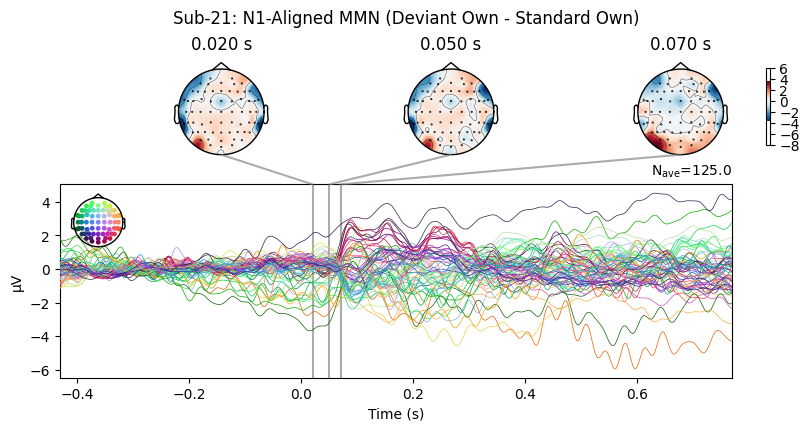

Computing Noise Covariance Matrix...
    Created an SSP operator (subspace dimension = 1)
    Setting small EEG eigenvalues to zero (without PCA)
Reducing data rank from 64 -> 63
Estimating covariance using SHRUNK


/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/archinarang/Library/Python/3.9/lib/pytho

Done.
Estimating covariance using DIAGONAL_FIXED
    EEG regularization : 0.1
Done.
Estimating covariance using EMPIRICAL
Done.
Using cross-validation to select the best estimator.
    EEG regularization : 0.1


/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: divide by zero encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:2311: RuntimeWarning: overflow encountered in slogdet
  sign, logdet = _umath_linalg.slogdet(a, signature=signature)
/Users/archinarang/Library/Python/3.9/lib/pytho

    EEG regularization : 0.1
    EEG regularization : 0.1
Number of samples used : 116250
log-likelihood on unseen data (descending order):
   shrunk: -130.185
   diagonal_fixed: -141.424
   empirical: -591.368
selecting best estimator: shrunk
[done]


/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: invalid value encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: divide by zero encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarning: overflow encountered in matmul
  B = (u * psigma_diag) @ u.conj().T
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1542: RuntimeWarn

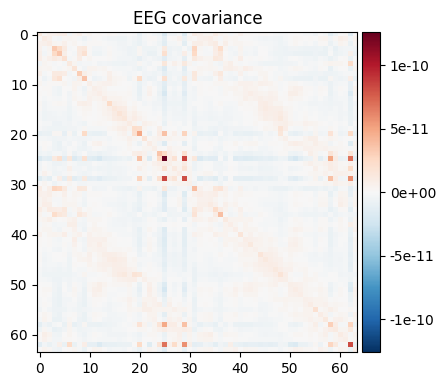

In [3]:
import mne
mne.viz.set_3d_backend('pyvistaqt')
import numpy as np
import matplotlib.pyplot as plt

#Load data
filepath = "/Users/archinarang/Desktop/NeuroProject/Preprocessed/sub-sd021-epo.fif"
epochs = mne.read_epochs(filepath, preload=True)

epochs.set_eeg_reference('average', projection=True).apply_proj()



# S14: Standard Own (Expected Notification)
# S15: Deviant Own (Surprise Notification)
sn_std = epochs['S14'].average()
sn_dev = epochs['S15'].average()

# N1 peak alignment
n1_window = sn_std.copy().pick(['Cz']).crop(tmin=0.05, tmax=0.15)
n1_idx = np.argmin(n1_window.data[0, :]) 
n1_time = n1_window.times[n1_idx]        

print(f"Subject 21's N1 Peak found at: {n1_time * 1000:.1f} ms")

# Shift both Evokeds so that the N1 peak becomes exactly t = 0.0s
sn_std.shift_time(-n1_time, relative=True)
sn_dev.shift_time(-n1_time, relative=True)


# MMN = [Deviant] - [Standard]
mmn_evoked = mne.combine_evoked([sn_dev, sn_std], weights=[1, -1])

# Plot the resulting MMN to verify
fig1 = mmn_evoked.plot_joint(times=[0.02, 0.05, 0.07], 
                             title="Sub-21: N1-Aligned MMN (Deviant Own - Standard Own)")


# Calculate background noise using the pre-stimulus baseline of the Standard trials
print("Computing Noise Covariance Matrix...")
noise_cov = mne.compute_covariance(epochs['S14'], tmin=-0.3, tmax=0.0, 
                                   method='auto', rank=None, verbose=True)

# Plot the Covariance Matrix to verify amplifier noise is handled
fig2 = mne.viz.plot_cov(noise_cov, epochs.info, show_svd=False)

plt.show()

In [5]:
import os.path as op
from mne.minimum_norm import make_inverse_operator, apply_inverse


# making virtual head 
print("\nFetching fsaverage template brain...")
fs_dir = mne.datasets.fetch_fsaverage(verbose=False)
subjects_dir = op.dirname(fs_dir)

# Ensure electrodes are locked to the standard 10-20 layout
mmn_evoked.set_montage('standard_1020', match_case=False, on_missing='ignore')

# important 
trans = 'fsaverage'  
src = op.join(fs_dir, 'bem', 'fsaverage-ico-5-src.fif')
bem = op.join(fs_dir, 'bem', 'fsaverage-5120-5120-5120-bem-sol.fif')

print("Calculating Forward Solution (Leadfield Matrix)...")
fwd = mne.make_forward_solution(mmn_evoked.info, trans=trans, src=src,
                                bem=bem, eeg=True, meg=False, verbose=False)

# inverse operator 
print("Building Inverse Operator...")

inv = make_inverse_operator(mmn_evoked.info, fwd, noise_cov, 
                            loose=0.2, depth=0.8, verbose=False)

# Apply sLORETA to your MMN Difference Wave
snr = 3.0
lambda2 = 1.0 / snr ** 2
print("Applying sLORETA to the MMN...")
stc = apply_inverse(mmn_evoked, inv, lambda2, method='sLORETA', verbose=False)

# plotting
brain = stc.plot(subjects_dir=subjects_dir, subject='fsaverage', surface='inflated', 
                 hemi='both', views=['lat', 'med'], initial_time=0.050, 
                 time_viewer=True, size=(800, 400))


Fetching fsaverage template brain...
Calculating Forward Solution (Leadfield Matrix)...


/Users/archinarang/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: divide by zero encountered in matmul
  weights = np.matmul(
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: overflow encountered in matmul
  weights = np.matmul(
/Users/archinarang/Library/Python/3.9/lib/python/site-packages/mne/forward/_compute_forward.py:256: RuntimeWarning: invalid value encountered in matmul
  weights = np.matmul(


Building Inverse Operator...
Applying sLORETA to the MMN...
Using control points [4.37314681 4.98753585 8.84201025]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
